In [ ]:
!curl -L "https://universe.roboflow.com/ds/Cl1wWrgQeY?key=91bcHQNszs" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/2013-01-18_09_30_05_jpg.rf.e8a3065c65924a69bd5bb755bbe5a4b5.txt  
  inflating: train/labels/2013-01-18_09_35_05_jpg.rf.36709ee017f4b0f3fe3dfdbe3a5c4de8.txt  
  inflating: train/labels/2013-01-18_09_40_05_jpg.rf.bac941910e526263264bc2b3b4f30d5d.txt  
  inflating: train/labels/2013-01-18_09_45_05_jpg.rf.236cdc191432bdedad549775b49d8db2.txt  
  inflating: train/labels/2013-01-18_09_50_05_jpg.rf.db568d16b599244861fa31eda89fed73.txt  
  inflating: train/labels/2013-01-18_09_55_05_jpg.rf.64b4da4b693e18f68a23b9ca2264384a.txt  
  inflating: train/labels/2013-01-18_10_00_05_jpg.rf.7db645f08647327b9059264884f12629.txt  
  inflating: train/labels/2013-01-18_10_05_06_jpg.rf.474ff01f6b7ae38ac5f4ad28fbcdce68.txt  
  inflating: train/labels/2013-01-18_10_10_06_jpg.rf.5017a99367bc2f62f37f5b302cb86ab9.txt  
  inflating: train/labels/2013-01-18_10_15_06_jpg.rf.7601056e8315f7cb1a248c71f35d9b2c.txt  
  inflating: train/labels/201

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define dataset path
IMAGES_DIR = "/content/train/images"
LABELS_DIR = "/content/train/labels"
IMAGE_SIZE = (256, 256)  # Resize images for UNet

import numpy as np
import cv2

def yolo_polygon_to_mask(image_shape, yolo_annotations, class_id=0):
    """
    Converts YOLOv8 polygon annotations to binary segmentation masks.
    - Uses OpenCV's `fillPoly()` to create pixel-wise masks.
    """
    mask = np.zeros(image_shape[:2], dtype=np.uint8)

    for ann in yolo_annotations:
        values = list(map(float, ann.strip().split()))
        if len(values) < 3:  # Ensure at least one (x, y) pair exists
            continue

        obj_class = int(values[0])
        if obj_class != class_id:  # Filter by class if needed
            continue

        # Extract polygon points
        points = np.array(values[1:]).reshape(-1, 2)  # Reshape into (N, 2) array
        points[:, 0] *= image_shape[1]  # Convert x from relative to absolute
        points[:, 1] *= image_shape[0]  # Convert y from relative to absolute
        points = points.astype(np.int32)

        # Fill the polygon mask
        cv2.fillPoly(mask, [points], color=1)

    return mask


# Custom dataset class
class ParkingDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_filenames = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        image_name = self.image_filenames[idx]
        image_path = os.path.join(self.images_dir, image_name)
        label_path = os.path.join(self.labels_dir, image_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Load image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load YOLO annotations
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                yolo_annotations = f.readlines()
        else:
            yolo_annotations = []

        # Convert bounding boxes to segmentation mask
        mask = yolo_polygon_to_mask(image.shape, yolo_annotations)

        # Resize image and mask
        image = cv2.resize(image, IMAGE_SIZE)
        mask = cv2.resize(mask, IMAGE_SIZE, interpolation=cv2.INTER_NEAREST)

        # Apply augmentations if available
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed["image"], transformed["mask"]

        return image, mask


In [ ]:
# Data Augmentation & Normalization
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
   # A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Initialize dataset and dataloader
dataset = ParkingDataset(IMAGES_DIR, LABELS_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Check dataset
for img, mask in dataloader:
    print(f"Image shape: {img.shape}, Mask shape: {mask.shape}")
    break


Image shape: torch.Size([8, 3, 256, 256]), Mask shape: torch.Size([8, 256, 256])


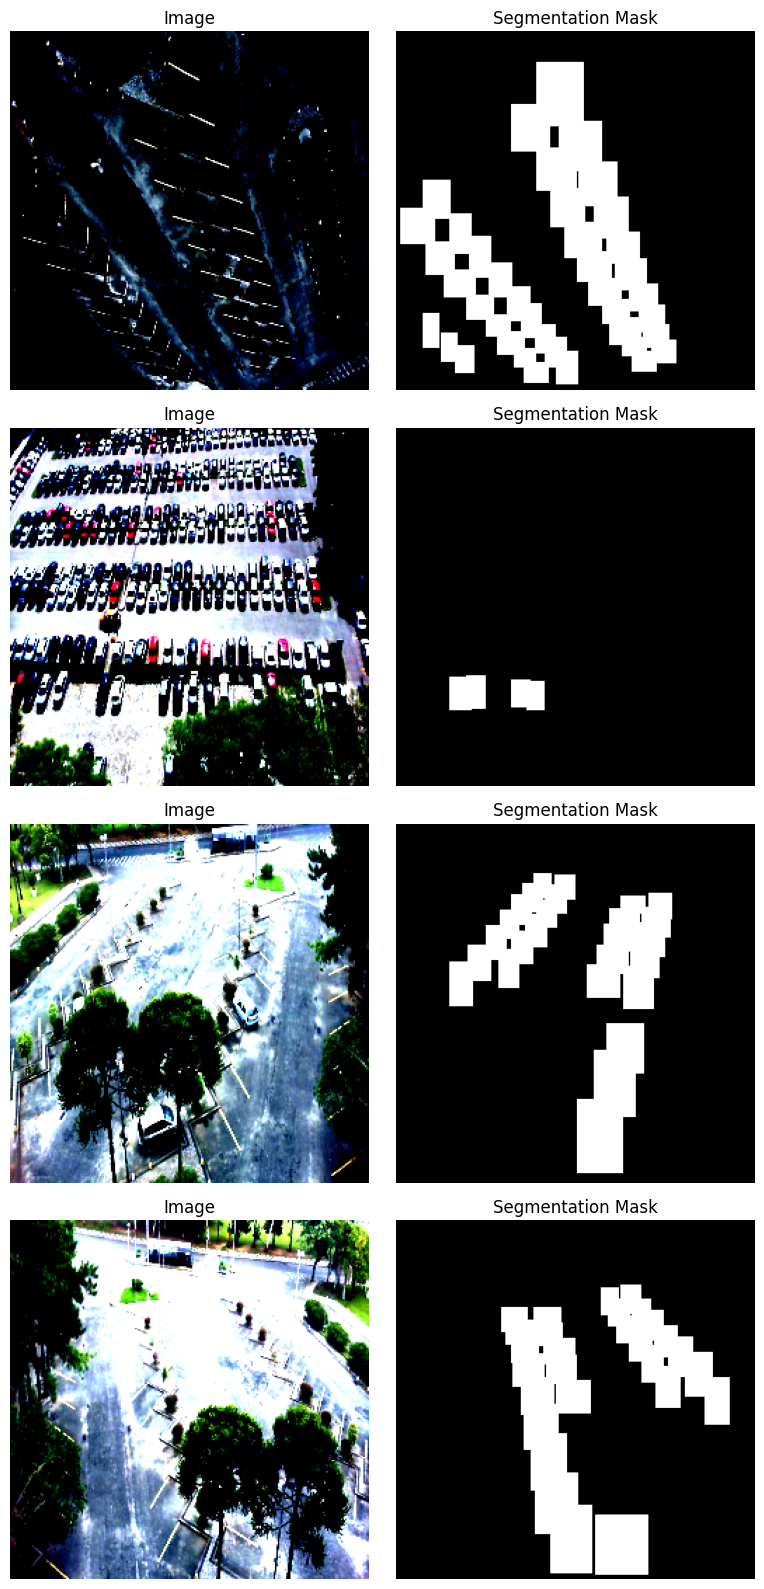

In [ ]:
import matplotlib.pyplot as plt

# Function to visualize dataset samples
def visualize_samples(dataset, num_samples=4):
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 4))

    for i in range(num_samples):
        image, mask = dataset[i]

        # Convert image tensor back to numpy format
        image_np = image.permute(1, 2, 0).cpu().numpy()
        mask_np = mask.cpu().numpy()  # Convert mask to numpy

        # Display image
        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        # Display mask
        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Segmentation Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# Visualize dataset
visualize_samples(dataset, num_samples=4)


In [ ]:
from torch.utils.data import random_split

# Define dataset sizes
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# UNet Model
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),  # Added BatchNorm to stabilize training
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.encoder1 = conv_block(in_channels, 64)
        self.encoder2 = conv_block(64, 128)
        self.encoder3 = conv_block(128, 256)
        self.encoder4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.upconv4(b)
        d4 = torch.cat((e4, d4), dim=1)
        d4 = self.decoder4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat((e3, d3), dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat((e2, d2), dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((e1, d1), dim=1)
        d1 = self.decoder1(d1)

        return self.final_conv(d1)  # Use sigmoid for binary segmentation

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

# Print model summary
print(model)


UNet(
  (encoder1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (encoder3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=T

In [ ]:
import torch.optim as optim


class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, pred, target, smooth=1e-6):
        pred = torch.sigmoid(pred)  # Ensure sigmoid activation
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice_score = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice_score.mean()

# Loss Function (Fix: Keep only one)
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def loss_fn(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


In [ ]:
from tqdm import tqdm

# Training function with target shape fix
def train_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=10):
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        loop = tqdm(train_loader, leave=True)

        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)

            masks = masks.unsqueeze(1).float()  # Reshape to [batch_size, 1, H, W]

            # Forward pass
            outputs = model(images)
            loss = loss_fn(outputs, masks)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_description(f"Epoch {epoch+1}/{epochs}")
            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1} Loss: {epoch_loss / len(train_loader):.4f}")

        # Validation Step
        validate_model(model, val_loader, loss_fn)

# Validation function
def validate_model(model, val_loader, loss_fn):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            masks = masks.unsqueeze(1).float()  # Reshape target

            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item()

    print(f"Validation Loss: {val_loss / len(val_loader):.4f}")
    model.train()


In [ ]:
train_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=10)


Epoch 1/10: 100%|██████████| 621/621 [08:13<00:00,  1.26it/s, loss=0.185]

Epoch 1 Loss: 0.2164


Validation Loss: 0.2040


Epoch 2/10: 100%|██████████| 621/621 [08:23<00:00,  1.23it/s, loss=0.119]

Epoch 2 Loss: 0.2138


...

Epoch 9 Loss: 0.1839


Validation Loss: 0.1791


Epoch 10/10: 100%|██████████| 621/621 [08:15<00:00,  1.25it/s, loss=0.12]

Epoch 10 Loss: 0.1783


Validation Loss: 0.1839


In [ ]:
# Save the entire model
torch.save(model.state_dict(), "unet_segmentation.pth")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
import torch
import cv2
import numpy as np
from torchvision import transforms

# Load the trained model
model = UNet().to(device)
model.load_state_dict(torch.load("unet_segmentation.pth", map_location=device))
model.eval()  # Set model to evaluation mode


UNet(
  (encoder1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (encoder2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (encoder3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=T

In [ ]:
# Load an image (Change path accordingly)
image_path = "/content/train/images/2012-09-11_15_29_29_jpg.rf.503db4ac1962559759137b816f6ae10f.jpg"  # Replace with your test image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
image_resized = cv2.resize(image, (256, 256))  # Resize to match model input size

# Convert image to tensor
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

input_tensor = transform(image_resized).unsqueeze(0).to(device)  # Add batch dimension


In [ ]:
# Run prediction
with torch.no_grad():
    output = model(input_tensor)

# Apply sigmoid and threshold to get binary mask
output = torch.sigmoid(output)
output = output.cpu().squeeze().numpy()  # Convert to numpy array
output = (output > 0.5).astype(np.uint8)  # Threshold at 0.5


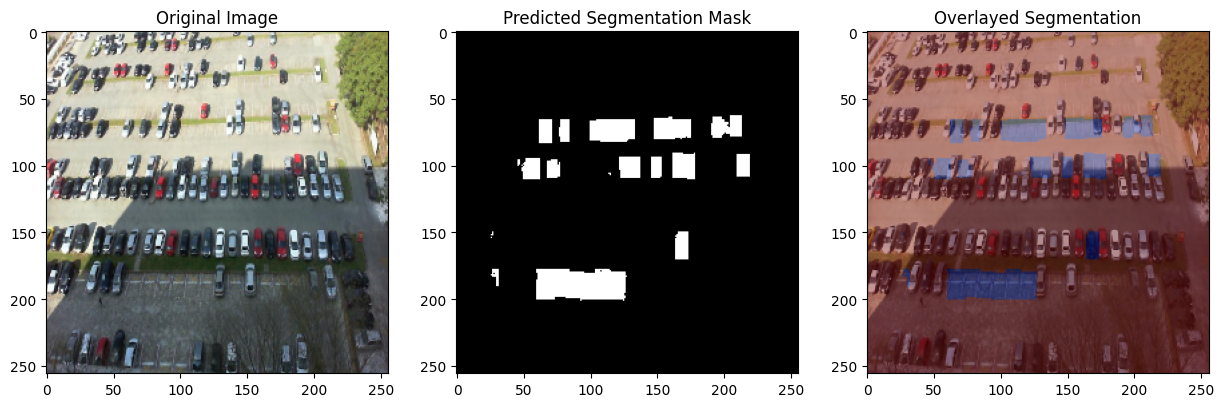

In [ ]:
# Create overlay
overlay = (output * 255).astype(np.uint8)  # Convert mask to 255 scale
overlay = cv2.applyColorMap(overlay, cv2.COLORMAP_JET)  # Apply colormap
overlay = cv2.addWeighted(image_resized, 0.6, overlay, 0.4, 0)  # Blend image with mask

# Plot results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_resized)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(output, cmap="gray")
plt.title("Predicted Segmentation Mask")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlayed Segmentation")

plt.show()

In [ ]:
import torch

# IOU Score (Jaccard Index)
def iou_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred) > 0.5  # Apply thresholding
    target = target.bool()

    intersection = (pred & target).sum(dim=(2, 3)).float()
    union = (pred | target).sum(dim=(2, 3)).float()

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# Dice Score
def dice_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred) > 0.5  # Apply thresholding
    target = target.bool()

    intersection = (pred & target).sum(dim=(2, 3)).float()
    dice = (2. * intersection + smooth) / (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)

    return dice.mean()

# Pixel Accuracy
def pixel_accuracy(pred, target):
    pred = torch.sigmoid(pred) > 0.5  # Apply thresholding
    correct = (pred == target).sum().float()
    total = target.numel()

    return correct / total


In [ ]:
# Convert NumPy array to Torch tensor
target_tensor = torch.tensor(output).unsqueeze(0).unsqueeze(0).to(device)  # Add batch & channel dims
pred_tensor = model(input_tensor)

# Compute Metrics
iou = iou_score(pred_tensor, target_tensor).item()
dice = dice_score(pred_tensor, target_tensor).item()
accuracy = pixel_accuracy(pred_tensor, target_tensor).item()

print(f"IOU Score: {iou:.4f}")
print(f"Dice Score: {dice:.4f}")
print(f"Pixel Accuracy: {accuracy:.4f}")


IOU Score: 1.0000
Dice Score: 1.0000
Pixel Accuracy: 1.0000


In [ ]:
!pip install pathfinding

In [ ]:
import cv2
import numpy as np
import os
from pathfinding.core.grid import Grid
from pathfinding.finder.a_star import AStarFinder
from ultralytics import YOLO
import tempfile
from PIL import Image
import torch
import time
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# For visualization
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]

In [ ]:
# Cell 2: Define utility functions
# Function to load the YOLOv8 model
def load_model(model_path):
    try:
        model = YOLO(model_path)
        return model
    except Exception as e:
        print(f"Failed to load model: {e}")
        return None

In [ ]:
# Function to detect parking slots using YOLOv8
def detect_parking_slots(image, model, conf_threshold=0.25):
    # Get image dimensions
    height, width = image.shape[:2]

    # Run detection
    results = model(image)

    # Parse results
    empty_slots = []
    occupied_slots = []

    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Get coordinates (x1, y1, x2, y2)
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

            # Get confidence
            conf = float(box.conf[0].cpu().numpy())

            # Only consider detections above confidence threshold
            if conf < conf_threshold:
                continue

            # Get class (0: empty, 1: occupied) - adjust based on your model's classes
            cls = int(box.cls[0].cpu().numpy())

            if cls == 0:  # Empty slot
                empty_slots.append((x1, y1, x2, y2, "empty", conf))
            else:  # Occupied slot
                occupied_slots.append((x1, y1, x2, y2, "occupied", conf))

    return empty_slots, occupied_slots

In [ ]:
# Function to create navigation grid with vehicle size consideration
def create_navigation_grid(image_shape, occupied_slots, vehicle_width=30, vehicle_length=60):
    # Create a binary grid where 1 = walkable, 0 = obstacle
    grid_data = np.ones((image_shape[0], image_shape[1]), dtype=int)

    # Mark occupied slots as non-walkable with vehicle dimensions buffer
    for slot in occupied_slots:
        x1, y1, x2, y2 = slot[:4]

        # Add a margin around obstacles based on vehicle size
        # Use vehicle_width/2 as the side clearance and vehicle_length/2 as front/back clearance
        buffer_x = vehicle_width // 2
        buffer_y = vehicle_length // 2

        # Apply buffer
        x1_buffered = max(0, x1 - buffer_x)
        y1_buffered = max(0, y1 - buffer_y)
        x2_buffered = min(image_shape[1] - 1, x2 + buffer_x)
        y2_buffered = min(image_shape[0] - 1, y2 + buffer_y)

        grid_data[y1_buffered:y2_buffered, x1_buffered:x2_buffered] = 0

    # Apply image processing to ensure corridors are wide enough for vehicles
    # Dilate obstacles to ensure paths are at least as wide as the vehicle
    kernel_size = vehicle_width // 2  # Half vehicle width for the kernel
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    obstacle_map = (1 - grid_data).astype(np.uint8)  # Invert to get obstacles as 1
    dilated_obstacles = cv2.dilate(obstacle_map, kernel, iterations=1)

    # Convert back to grid format (1 for walkable, 0 for obstacles)
    grid_data = 1 - dilated_obstacles

    # Create the pathfinding grid
    return Grid(matrix=grid_data.tolist())


In [ ]:
# Function to find nearest navigable point
def find_nearest_navigable_point(grid, x, y, max_radius=50):
    """Find the nearest navigable point to the given coordinates."""
    for radius in range(1, max_radius):
        # Check points in increasing radius around the given point
        for i in range(-radius, radius + 1):
            for j in range(-radius, radius + 1):
                # Only check points at the current radius (perimeter)
                if abs(i) == radius or abs(j) == radius:
                    check_x = x + i
                    check_y = y + j

                    # Check if within grid bounds and walkable
                    if (0 <= check_x < grid.width and
                        0 <= check_y < grid.height and
                        grid.node(check_x, check_y).walkable):
                        return (check_x, check_y)
    return None


In [ ]:
# Function to find path with vehicle constraints
def find_path(grid, start_point, end_point):
    # Use A* algorithm for pathfinding
    finder = AStarFinder(diagonal_movement=True)

    # Check if points are within grid bounds
    start_x = min(max(start_point[0], 0), grid.width - 1)
    start_y = min(max(start_point[1], 0), grid.height - 1)
    end_x = min(max(end_point[0], 0), grid.width - 1)
    end_y = min(max(end_point[1], 0), grid.height - 1)

    # Ensure start and end points are in navigable areas
    if not grid.node(start_x, start_y).walkable:
        # Find nearest navigable point to start
        nearest_start = find_nearest_navigable_point(grid, start_x, start_y)
        if nearest_start:
            start_x, start_y = nearest_start
        else:
            print("Cannot find navigable area near entrance. Please adjust entrance position.")
            return []

    if not grid.node(end_x, end_y).walkable:
        # Find nearest navigable point to end
        nearest_end = find_nearest_navigable_point(grid, end_x, end_y)
        if nearest_end:
            end_x, end_y = nearest_end
        else:
            print("Cannot find navigable area near target. Please select a different parking slot.")
            return []

    start = grid.node(start_x, start_y)
    end = grid.node(end_x, end_y)

    try:
        path, _ = finder.find_path(start, end, grid)
        return path
    except Exception as e:
        print(f"Path finding error: {e}")
        return []


In [ ]:
# Function to smooth path for vehicle movement
def smooth_path(path, smoothing_window=3):
    """Apply smoothing to the path to make it more suitable for vehicles."""
    if len(path) < smoothing_window * 2:
        return path

    smoothed_path = [path[0]]  # Keep the start point

    # Apply moving average to middle points
    for i in range(1, len(path) - 1):
        # Get window of points
        window_start = max(0, i - smoothing_window)
        window_end = min(len(path), i + smoothing_window + 1)
        window = path[window_start:window_end]

        # Calculate average position
        avg_x = sum(node.x for node in window) // len(window)
        avg_y = sum(node.y for node in window) // len(window)

        # Modify the existing node's coordinates
        path[i].x = avg_x
        path[i].y = avg_y
        smoothed_path.append(path[i])

    smoothed_path.append(path[-1])  # Keep the end point

    return smoothed_path


In [ ]:
# Function to draw the image with detections and navigation
def draw_detections(image, empty_slots=None, occupied_slots=None, entrance_point=None, target_point=None, path=None):
    # Make a copy of the image
    display_img = image.copy()

    # Draw empty slots in green
    if empty_slots:
        for slot in empty_slots:
            x1, y1, x2, y2, _, conf = slot
            cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Label with confidence
            label = f"Empty {conf:.2f}"
            cv2.putText(display_img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Draw occupied slots in red
    if occupied_slots:
        for slot in occupied_slots:
            x1, y1, x2, y2, _, conf = slot
            cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            # Label with confidence
            label = f"Occupied {conf:.2f}"
            cv2.putText(display_img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # Draw path if available
    if path and entrance_point and target_point:
        # Draw entrance point as a yellow circle
        cv2.circle(display_img, entrance_point, 12, (0, 255, 255), -1)
        cv2.putText(display_img, "Entrance", (entrance_point[0]-30, entrance_point[1]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 4)
        cv2.putText(display_img, "Entrance", (entrance_point[0]-30, entrance_point[1]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

        # Draw target point as a magenta circle
        cv2.circle(display_img, target_point, 12, (255, 0, 255), -1)
        cv2.putText(display_img, "Target", (target_point[0]-30, target_point[1]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 4)
        cv2.putText(display_img, "Target", (target_point[0]-30, target_point[1]-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 255), 2)

        # Draw path as a blue line
        for i in range(len(path) - 1):
            pt1 = (path[i].x, path[i].y)
            pt2 = (path[i + 1].x, path[i + 1].y)
            cv2.line(display_img, pt1, pt2, (255, 0, 0), 5)

    return display_img

In [ ]:
# Helper function to visualize vehicle width along the path
def visualize_vehicle_width(img, path, vehicle_width):
    nav_with_vehicle = img.copy()
    if len(path) > 1:
        for i in range(len(path) - 1):
            pt1 = (path[i].x, path[i].y)
            pt2 = (path[i + 1].x, path[i + 1].y)

            # Calculate the direction vector
            dx = pt2[0] - pt1[0]
            dy = pt2[1] - pt1[1]
            # Normalize
            length = max(1, ((dx**2 + dy**2)**0.5))
            dx, dy = dx/length, dy/length
            # Get perpendicular vector
            perp_x, perp_y = -dy, dx

            # Draw vehicle width (perpendicular to path)
            half_width = vehicle_width // 2
            # Left side of vehicle
            left1 = (int(pt1[0] + perp_x * half_width), int(pt1[1] + perp_y * half_width))
            left2 = (int(pt2[0] + perp_x * half_width), int(pt2[1] + perp_y * half_width))
            # Right side of vehicle
            right1 = (int(pt1[0] - perp_x * half_width), int(pt1[1] - perp_y * half_width))
            right2 = (int(pt2[0] - perp_x * half_width), int(pt2[1] - perp_y * half_width))

            # Draw vehicle outline
            cv2.line(nav_with_vehicle, left1, left2, (255, 200, 0), 1)
            cv2.line(nav_with_vehicle, right1, right2, (255, 200, 0), 1)

            # Connect front and back
            if i == 0:
                cv2.line(nav_with_vehicle, left1, right1, (255, 200, 0), 1)
            if i == len(path) - 2:
                cv2.line(nav_with_vehicle, left2, right2, (255, 200, 0), 1)

    return nav_with_vehicle

In [ ]:
# Cell 3: Load image and model
# Load your image - replace with your actual image path
image_path = "/content/8a3f28c1-4b21-4ff3-8a92-706f35fabda3.jpeg"  # Replace with your image path
image = cv2.imread(image_path)

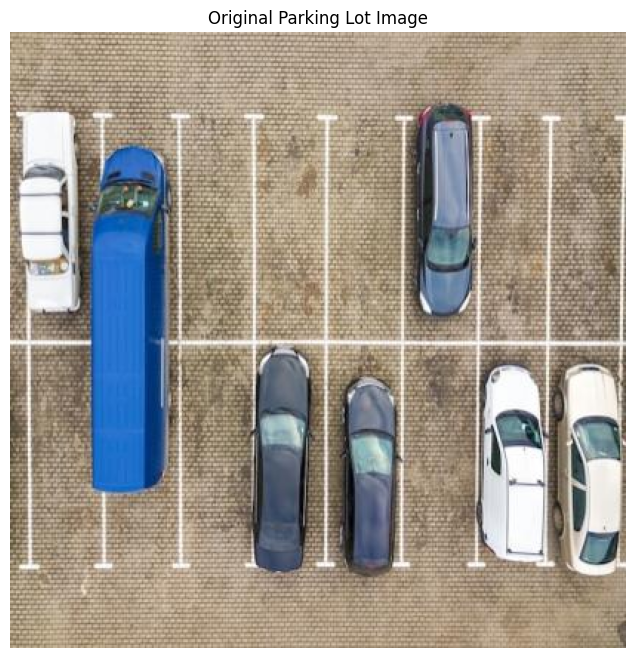

In [ ]:
if image is None:
    print(f"Failed to load image from {image_path}")
else:
    # Convert BGR to RGB for display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(12, 8))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title("Original Parking Lot Image")
    plt.show()

    # Load the YOLOv8 model - replace with your model path
    model_path = "best.pt"  # Replace with your model path
    model = load_model(model_path)

    if model is None:
        print("Failed to load model. Please check the model path.")


In [ ]:
# Cell 4: Detect parking slots
# Set confidence threshold
conf_threshold = 0.01

In [ ]:
# Detect parking slots
occupied_slots,empty_slots = detect_parking_slots(image_rgb, model, conf_threshold)


0: 640x640 9 Cars, 8 Emptys, 10.4ms
Speed: 2.9ms preprocess, 10.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
# Print detection results
print(f"Detected {len(empty_slots)} empty slots and {len(occupied_slots)} occupied slots")

Detected 8 empty slots and 9 occupied slots


In [ ]:
# Calculate occupancy rate
total_slots = len(empty_slots) + len(occupied_slots)
occupancy_rate = round((len(occupied_slots) / total_slots * 100 if total_slots > 0 else 0), 1)
print(f"Occupancy rate: {occupancy_rate}%")

Occupancy rate: 52.9%


In [ ]:
# Draw detections on the image
display_img = draw_detections(image_rgb, empty_slots, occupied_slots)

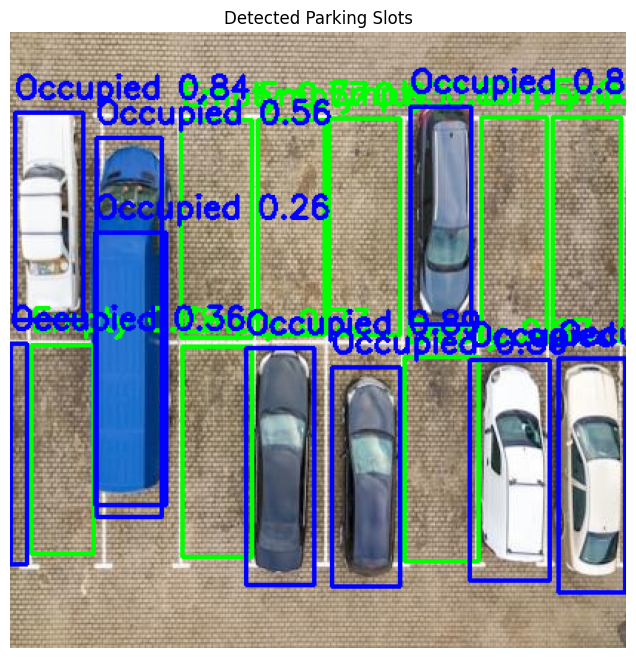

In [ ]:
# Display the result
plt.figure(figsize=(12, 8))
plt.imshow(display_img)
plt.axis('off')
plt.title("Detected Parking Slots")
plt.show()

In [ ]:
# Cell 5: Display empty slots for selection
# Display information about empty slots
print("\nAvailable Empty Slots:")
print("----------------------")
for i, slot in enumerate(empty_slots):
    x1, y1, x2, y2, _, conf = slot
    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2
    print(f"Slot #{i+1}: Confidence: {conf:.2f}, Center position: ({center_x}, {center_y})")


Available Empty Slots:
----------------------
Slot #1: Confidence: 0.87, Center position: (291, 288)
Slot #2: Confidence: 0.86, Center position: (389, 132)
Slot #3: Confidence: 0.83, Center position: (239, 131)
Slot #4: Confidence: 0.79, Center position: (340, 132)
Slot #5: Confidence: 0.77, Center position: (139, 132)
Slot #6: Confidence: 0.73, Center position: (139, 283)
Slot #7: Confidence: 0.72, Center position: (35, 281)
Slot #8: Confidence: 0.63, Center position: (189, 131)


In [ ]:
# Create a dictionary to store slot information
slot_options = {}
for i, slot in enumerate(empty_slots):
    x1, y1, x2, y2, _, conf = slot
    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2
    slot_options[i+1] = (slot, (center_x, center_y))

In [ ]:
selected_slot_num = 6  # This will be set by user input in the next cell
entrance_x = 139
entrance_y = 283

In [ ]:
selected_slot_num = int(input("Enter the slot number you want to navigate to: "))

Enter the slot number you want to navigate to: 8


Selected slot #8 at position (np.int64(189), np.int64(131))
Use default entrance point? (y/n): y
Entrance point set to: (208, 386)


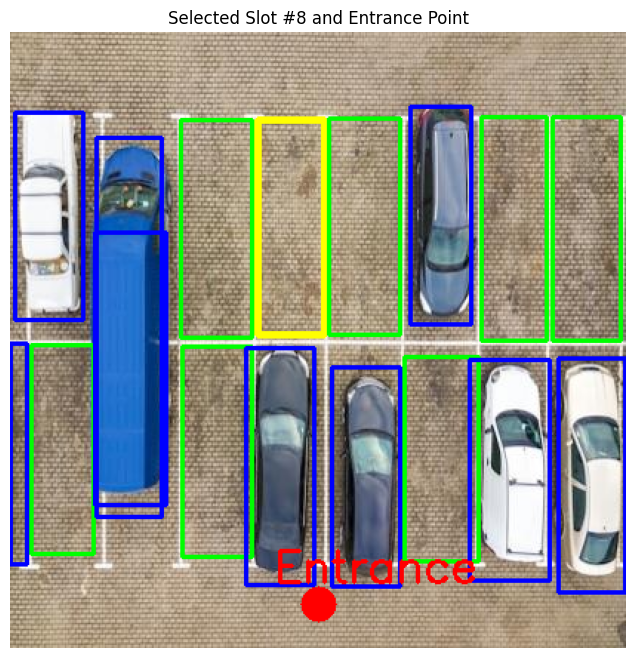

In [ ]:
if selected_slot_num not in slot_options:
    print(f"Invalid slot number. Please choose a number between 1 and {len(empty_slots)}")
else:
    selected_slot, target_point = slot_options[selected_slot_num]
    print(f"Selected slot #{selected_slot_num} at position {target_point}")

    # Default entrance point (bottom middle of the image)
    default_entrance_x = image_rgb.shape[1] // 2
    default_entrance_y = image_rgb.shape[0] - 30

    # Get user input for entrance point or use default
    use_default = input("Use default entrance point? (y/n): ").lower() == 'y'

    if use_default:
        entrance_x = default_entrance_x
        entrance_y = default_entrance_y
    else:
        entrance_x = int(input(f"Enter entrance X coordinate (0-{image_rgb.shape[1]-1}): "))
        entrance_y = int(input(f"Enter entrance Y coordinate (0-{image_rgb.shape[0]-1}): "))

    entrance_point = (entrance_x, entrance_y)
    print(f"Entrance point set to: {entrance_point}")

    # Preview the selected slot and entrance point
    preview_img = image_rgb.copy()
    selected_x1, selected_y1, selected_x2, selected_y2, _, _ = selected_slot

    # Draw the selected slot in yellow
    cv2.rectangle(preview_img, (selected_x1, selected_y1), (selected_x2, selected_y2), (255, 255, 0), 3)

    # Draw all other slots in their respective colors
    for slot in empty_slots:
        if slot != selected_slot:
            x1, y1, x2, y2, _, _ = slot
            cv2.rectangle(preview_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    for slot in occupied_slots:
        x1, y1, x2, y2, _, _ = slot
        cv2.rectangle(preview_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # Mark entrance point
    cv2.circle(preview_img, entrance_point, 12, (255, 0, 0), -1)
    cv2.putText(preview_img, "Entrance", (entrance_point[0]-30, entrance_point[1]-15),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(preview_img)
    plt.axis('off')
    plt.title(f"Selected Slot #{selected_slot_num} and Entrance Point")
    plt.show()


In [ ]:
# Cell 8: Vehicle size settings
# Set vehicle size parameters
vehicle_width = 20  # default width in pixels
vehicle_length = 30  # default length in pixels

# Get user input for vehicle size
change_vehicle_size = input("Change default vehicle size? (y/n): ").lower() == 'y'


Change default vehicle size? (y/n): n


In [ ]:
if change_vehicle_size:
    vehicle_width = int(input("Enter vehicle width in pixels (recommended: 20-100): "))
    vehicle_length = int(input("Enter vehicle length in pixels (recommended: 40-150): "))

print(f"Vehicle size set to: Width={vehicle_width}px, Length={vehicle_length}px")


Vehicle size set to: Width=20px, Length=30px


Calculating navigation path...
Path found with 319 steps
Estimated distance: 337.1 units


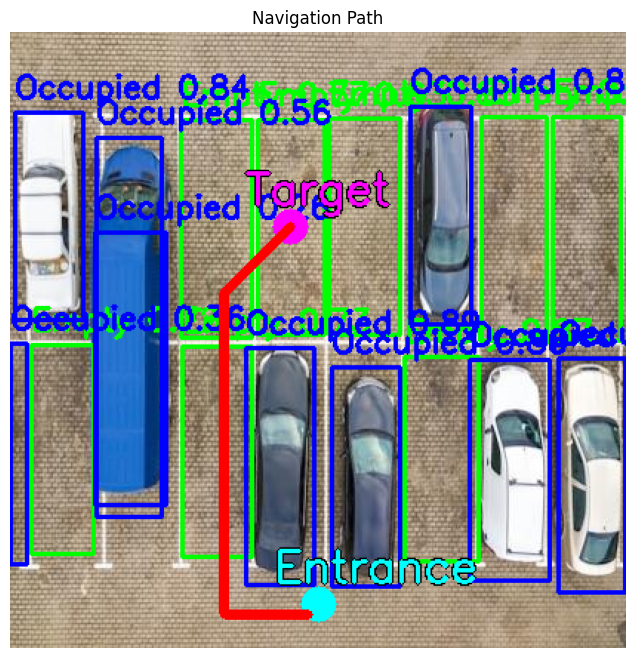

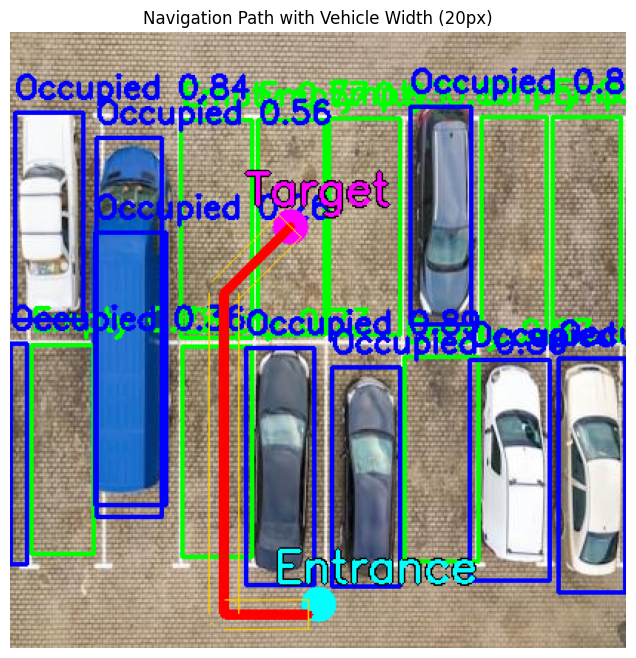

Save the navigation image? (y/n): y
Enter output file path (e.g., 'navigation_result.jpg'): navigation_result.jpg
Image saved to navigation_result.jpg


In [ ]:
# Cell 9: Generate navigation path
if selected_slot_num in slot_options and entrance_x is not None and entrance_y is not None:
    selected_slot, target_point = slot_options[selected_slot_num]
    entrance_point = (entrance_x, entrance_y)

    print("Calculating navigation path...")

    # Create grid with vehicle size consideration
    grid = create_navigation_grid(
        image_rgb.shape,
        occupied_slots,
        vehicle_width=vehicle_width,
        vehicle_length=vehicle_length
    )

    # Find path
    path = find_path(grid, entrance_point, target_point)

    if path:
        print(f"Path found with {len(path)} steps")

        # Calculate estimated distance
        distance = sum(
            ((path[i+1].x - path[i].x)**2 + (path[i+1].y - path[i].y)**2)**0.5
            for i in range(len(path)-1)
        )
        print(f"Estimated distance: {distance:.1f} units")

        # Draw navigation on the image
        navigation_img = draw_detections(
            image_rgb,
            empty_slots,
            occupied_slots,
            entrance_point,
            target_point,
            path
        )

        # Display the navigation result
        plt.figure(figsize=(12, 8))
        plt.imshow(navigation_img)
        plt.axis('off')
        plt.title("Navigation Path")
        plt.show()

        # Visualize the vehicle width along the path
        nav_with_vehicle = visualize_vehicle_width(navigation_img, path, vehicle_width)

        # Display with vehicle width visualization
        plt.figure(figsize=(12, 8))
        plt.imshow(nav_with_vehicle)
        plt.axis('off')
        plt.title(f"Navigation Path with Vehicle Width ({vehicle_width}px)")
        plt.show()

        # Option to save the navigation image
        save_image = input("Save the navigation image? (y/n): ").lower() == 'y'
        if save_image:
            output_path = input("Enter output file path (e.g., 'navigation_result.jpg'): ")
            # Convert RGB to BGR for OpenCV
            nav_with_vehicle_bgr = cv2.cvtColor(nav_with_vehicle, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, nav_with_vehicle_bgr)
            print(f"Image saved to {output_path}")
    else:
        print("No path found. Please try a different slot or adjust entrance position.")
else:
    print("Please select a valid slot and set entrance point before generating a path.")